# Regressão Linear — Modelo Principal e Experimento com USD/BRL(t)

Este notebook executa a Regressão Linear como modelo baseline, mantendo a mesma estrutura de dados, divisão temporal e métricas utilizadas no projeto.

A única diferença entre as duas especificações é a inclusão ou não de `USD/BRL(t)` como variável explicativa.

- **Modelo principal:** 9 variáveis explicativas.
- **Experimento alternativo:** 9 variáveis + `USD/BRL(t)`.
- **Target:** `USD_BRL_t1`.
- **Divisão:** 80% treino / 20% teste, preservando a ordem temporal.
- **Padronização:** `StandardScaler` ajustado somente no conjunto de treino.


## Etapa 1 — Configuração dos caminhos e experimento

Altere somente `EXPERIMENTO_USD_T` para alternar entre o modelo principal e o experimento com `USD/BRL(t)`.

Os dois caminhos principais do notebook são:

- `PATH_FILE`: base de entrada do experimento;
- `PATH_TO_SAVE`: pasta onde todos os resultados da execução serão salvos.

Os caminhos são definidos automaticamente a partir de `EXPERIMENTO_USD_T`.


In [42]:
from pathlib import Path

# ============================================================
# CONFIGURAÇÃO PRINCIPAL
# ============================================================

# False -> Modelo principal
# True  -> Experimento com USD/BRL(t)
EXPERIMENTO_USD_T = True

# Raiz do projeto
PROJECT_ROOT = Path(r"C:\Projetos\PTAX_PREDICTION_MBA_TCC")

# ============================================================
# BASES DE ENTRADA
# ============================================================

PATH_FILE_PRINCIPAL = (
    PROJECT_ROOT
    / "dados"
    / "tratado"
    / "consolidado_sem_nulos_final_usdt1.csv"
)

PATH_FILE_ALTERNATIVO = (
    PROJECT_ROOT
    / "dados"
    / "tratado"
    / "consolidado_sem_nulos_final_usdt1.csv"
)

# ============================================================
# PASTAS DE RESULTADOS
# ============================================================

PATH_SAVE_PRINCIPAL = (
    PROJECT_ROOT
    / "resultados"
    / "regressao_linear"
    / "modelo_principal"
)

PATH_SAVE_ALTERNATIVO = (
    PROJECT_ROOT
    / "resultados"
    / "regressao_linear"
    / "experimento_usd_t"
)

# ============================================================
# DEFINIÇÃO DOS DOIS PATHS UTILIZADOS PELO NOTEBOOK
# ============================================================

if EXPERIMENTO_USD_T:
    PATH_FILE = PATH_FILE_ALTERNATIVO
    PATH_TO_SAVE = PATH_SAVE_ALTERNATIVO
    NOME_EXPERIMENTO = "Experimento com USD/BRL(t)"
else:
    PATH_FILE = PATH_FILE_PRINCIPAL
    PATH_TO_SAVE = PATH_SAVE_PRINCIPAL
    NOME_EXPERIMENTO = "Modelo principal"

PATH_TO_SAVE.mkdir(
    parents=True,
    exist_ok=True
)

print("=" * 70)
print("CONFIGURAÇÃO")
print("=" * 70)
print(f"Experimento : {NOME_EXPERIMENTO}")
print(f"PATH_FILE   : {PATH_FILE}")
print(f"PATH_TO_SAVE: {PATH_TO_SAVE}")
print("=" * 70)


CONFIGURAÇÃO
Experimento : Experimento com USD/BRL(t)
PATH_FILE   : C:\Projetos\PTAX_PREDICTION_MBA_TCC\dados\tratado\consolidado_sem_nulos_final_usdt1.csv
PATH_TO_SAVE: C:\Projetos\PTAX_PREDICTION_MBA_TCC\resultados\regressao_linear\experimento_usd_t


## Etapa 2 — Importação das bibliotecas

In [43]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.preprocessing import StandardScaler
from arquivos_apoio.funcoes_apoio import dividir_treino_teste_tcc


## Etapa 3 — Carregamento,  preparação da base E Divisão temporal treino/teste

A primeira coluna do CSV é carregada diretamente como índice e convertida para `DatetimeIndex`.

A base é então ordenada cronologicamente.

A coluna `Data` não participa como variável explicativa.

A divisão é feita em 80% para treinamento e 20% para teste, sem embaralhamento.

A ordem temporal é preservada.


In [44]:
X_train, y_train, X_test, y_test = dividir_treino_teste_tcc(PATH_FILE, incluir_usd_t=EXPERIMENTO_USD_T)
target = "USD_BRL_t1"

variaveis_base = [
        "Selic",
        "IPCA",
        "PIB",
        "Exportacoes",
        "Importacoes",
        "FEDFUNDS",
        "IBOV",
        "SP500",
        "Petroleo"
    ]

variaveis_explicativas = variaveis_base.copy()

if EXPERIMENTO_USD_T:
    variaveis_explicativas.append("USD/BRL")


[OK] Base carregada.
[INFO] Dimensões iniciais: (2600, 11)
[OK] Índice convertido para DatetimeIndex.
[OK] Base ordenada cronologicamente.
[OK] Não existem valores nulos.
[OK] Não existem valores infinitos.

DIVISÃO TREINO / TESTE
[INFO] Configuração: Experimento com USD/BRL(t)
[INFO] Variáveis explicativas: 10
[INFO] Variáveis: ['Selic', 'IPCA', 'PIB', 'Exportacoes', 'Importacoes', 'FEDFUNDS', 'IBOV', 'SP500', 'Petroleo', 'USD/BRL']
[INFO] Observações totais: 2600
[INFO] Treino: 2080 (80.0%)
[INFO] Teste: 520 (20.0%)
[INFO] Período treino: 2016-05-02 a 2024-04-24
[INFO] Período teste: 2024-04-25 a 2026-04-29
[OK] Ordem temporal preservada.
[OK] Sem sobreposição temporal.
[OK] Target: USD_BRL_t1


## Etapa 5 — Padronização das variáveis

O `StandardScaler` é ajustado exclusivamente sobre `X_train`.

O conjunto de teste utiliza apenas a transformação produzida pelo scaler ajustado no treino.


In [45]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

print("[OK] StandardScaler ajustado somente em X_train.")
print("[OK] X_train transformado.")
print("[OK] X_test transformado.")


[OK] StandardScaler ajustado somente em X_train.
[OK] X_train transformado.
[OK] X_test transformado.


## Etapa 6 — Treinamento da Regressão Linear

In [46]:
modelo_lr = LinearRegression()

modelo_lr.fit(
    X_train_scaled,
    y_train
)

print("[OK] LinearRegression treinado.")


[OK] LinearRegression treinado.


## Etapa 7 — Geração das previsões

In [47]:
y_pred_train = modelo_lr.predict(
    X_train_scaled
)

y_pred_test = modelo_lr.predict(
    X_test_scaled
)

previsoes_treino = pd.DataFrame({
    "Data": X_train.index,
    "y_real": np.asarray(y_train),
    "y_pred": y_pred_train
})

previsoes_teste = pd.DataFrame({
    "Data": X_test.index,
    "y_real": np.asarray(y_test),
    "y_pred": y_pred_test
})

print("[OK] Previsões de treino geradas.")
print("[OK] Previsões de teste geradas.")


[OK] Previsões de treino geradas.
[OK] Previsões de teste geradas.


## Etapa 8 — Avaliação do modelo

São calculadas MAE, RMSE e R² para treino e teste.


In [48]:
def calcular_metricas(
    y_real,
    y_pred,
    nome_modelo,
    conjunto
):
    return {
        "Modelo": nome_modelo,
        "Conjunto": conjunto,
        "MAE": mean_absolute_error(
            y_real,
            y_pred
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                y_real,
                y_pred
            )
        ),
        "R2": r2_score(
            y_real,
            y_pred
        )
    }


metricas = pd.DataFrame([
    calcular_metricas(
        y_train,
        y_pred_train,
        "Regressao Linear Baseline",
        "Treino"
    ),
    calcular_metricas(
        y_test,
        y_pred_test,
        "Regressao Linear Baseline",
        "Teste"
    )
])

display(metricas)


,Modelo,Conjunto,MAE,RMSE,R2
0,Regressao Linear Baseline,Treino,0.034087,0.048129,0.996951
1,Regressao Linear Baseline,Teste,0.035146,0.047056,0.969079


## Etapa 9 — Coeficientes do modelo

Os coeficientes são obtidos a partir do modelo ajustado sobre as variáveis padronizadas.


In [49]:
coeficientes = pd.DataFrame({
    "Variavel": X_train.columns,
    "Coeficiente": modelo_lr.coef_
})

print("Coeficientes:")
display(coeficientes)


Coeficientes:


,Variavel,Coeficiente
0,Selic,-0.010533
1,IPCA,-0.001721
2,PIB,0.033556
3,Exportacoes,-0.008051
4,Importacoes,0.002760
5,FEDFUNDS,-0.006334
6,IBOV,-0.009756
7,SP500,-0.002408
8,Petroleo,-0.002061
9,USD/BRL,0.857781


## Etapa 10 — OLS / Statsmodels

O OLS é calculado utilizando as variáveis de treinamento já padronizadas, mantendo a mesma especificação utilizada pela Regressão Linear.


In [50]:
X_train_ols = sm.add_constant(
    X_train_scaled,
    has_constant="add"
)

modelo_ols = sm.OLS(
    y_train,
    X_train_ols
).fit()

print(modelo_ols.summary())


                            OLS Regression Results                            
Dep. Variable:             USD_BRL_t1   R-squared:                       0.997
Model:                            OLS   Adj. R-squared:                  0.997
Method:                 Least Squares   F-statistic:                 6.765e+04
Date:                Wed, 30 Sep 2026   Prob (F-statistic):               0.00
Time:                        22:16:35   Log-Likelihood:                 3359.1
No. Observations:                2080   AIC:                            -6696.
Df Residuals:                    2069   BIC:                            -6634.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.4203      0.001   4177.545      0.0

## Etapa 11 — Baseline ingênuo

O baseline de persistência utiliza:

$$
\hat{y}(t+1) = USD/BRL(t)
$$

O valor de `USD/BRL(t)` é recuperado da mesma base definitiva, utilizando exatamente as datas do conjunto de teste.


In [51]:
# A base definitiva precisa conter USD/BRL(t)
df_base_naive = pd.read_csv(
    PATH_FILE,
    index_col=0
)

df_base_naive.index = pd.to_datetime(
    df_base_naive.index,
    errors="coerce"
)

df_base_naive = df_base_naive.sort_index()

if "USD/BRL" not in df_base_naive.columns:
    raise KeyError(
        "A coluna 'USD/BRL' não foi encontrada. "
        "O baseline ingênuo não pode ser calculado."
    )

if target not in df_base_naive.columns:
    raise KeyError(
        f"A coluna '{target}' não foi encontrada."
    )

df_teste_naive = pd.DataFrame({
    "Data": X_test.index,
    "Real": np.asarray(y_test)
})

df_base_aux = df_base_naive[
    ["USD/BRL", target]
].copy()

df_base_aux = df_base_aux.rename_axis(
    "Data"
).reset_index()

df_teste_naive = df_teste_naive.merge(
    df_base_aux,
    on="Data",
    how="left",
    validate="one_to_one"
)

if df_teste_naive["USD/BRL"].isna().any():
    raise ValueError(
        "Existem datas do teste sem USD/BRL(t) na base."
    )

if not np.allclose(
    df_teste_naive[target].to_numpy(),
    df_teste_naive["Real"].to_numpy(),
    rtol=1e-10,
    atol=1e-10
):
    raise ValueError(
        "O target da base definitiva não coincide com y_test."
    )

y_pred_naive = (
    df_teste_naive["USD/BRL"]
    .to_numpy()
)

metricas_naive = pd.DataFrame([{
    "Modelo": "Baseline Naive",
    "Conjunto": "Teste",
    "MAE": mean_absolute_error(
        y_test,
        y_pred_naive
    ),
    "RMSE": np.sqrt(
        mean_squared_error(
            y_test,
            y_pred_naive
        )
    ),
    "R2": r2_score(
        y_test,
        y_pred_naive
    )
}])

previsoes_naive = pd.DataFrame({
    "Data": X_test.index,
    "Real": np.asarray(y_test),
    "Previsto_Naive": y_pred_naive
})

display(metricas_naive)


,Modelo,Conjunto,MAE,RMSE,R2
0,Baseline Naive,Teste,0.033909,0.046417,0.969913


## Etapa 12 — Comparação entre Regressão Linear e baseline ingênuo

In [52]:
metricas_linear_teste = metricas[
    metricas["Conjunto"] == "Teste"
].copy()

comparacao = pd.concat(
    [
        metricas_linear_teste,
        metricas_naive
    ],
    ignore_index=True
)

display(comparacao)


,Modelo,Conjunto,MAE,RMSE,R2
0,Regressao Linear Baseline,Teste,0.035146,0.047056,0.969079
1,Baseline Naive,Teste,0.033909,0.046417,0.969913


## Etapa 13 — Resíduos da Regressão Linear

In [53]:
residuos_treino = (
    np.asarray(y_train) -
    np.asarray(y_pred_train)
)

residuos_teste = (
    np.asarray(y_test) -
    np.asarray(y_pred_test)
)

residuos_treino_df = pd.DataFrame({
    "Data": X_train.index,
    "Real": np.asarray(y_train),
    "Previsto": y_pred_train,
    "Residuo": residuos_treino
})

residuos_teste_df = pd.DataFrame({
    "Data": X_test.index,
    "Real": np.asarray(y_test),
    "Previsto": y_pred_test,
    "Residuo": residuos_teste
})

display(residuos_teste_df.head())


,Data,Real,Previsto,Residuo
0,2024-04-25,5.1586,5.157506,0.001094
1,2024-04-26,5.1155,5.169374,-0.053874
2,2024-04-29,5.1170,5.126685,-0.009684
3,2024-04-30,5.1939,5.129108,0.064792
4,2024-05-01,5.1944,5.198496,-0.004097


## Etapa 14 — Gráficos de diagnóstico

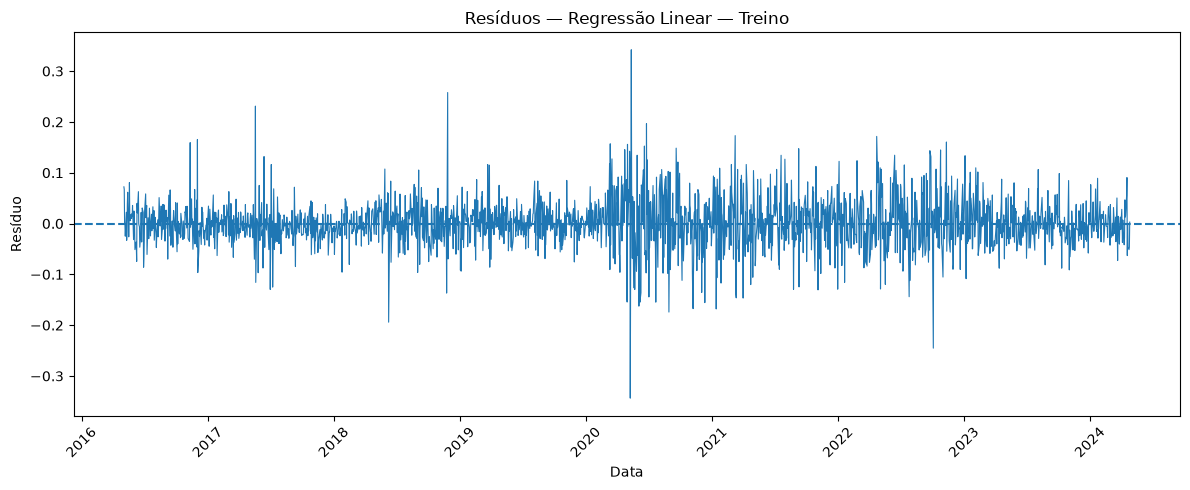

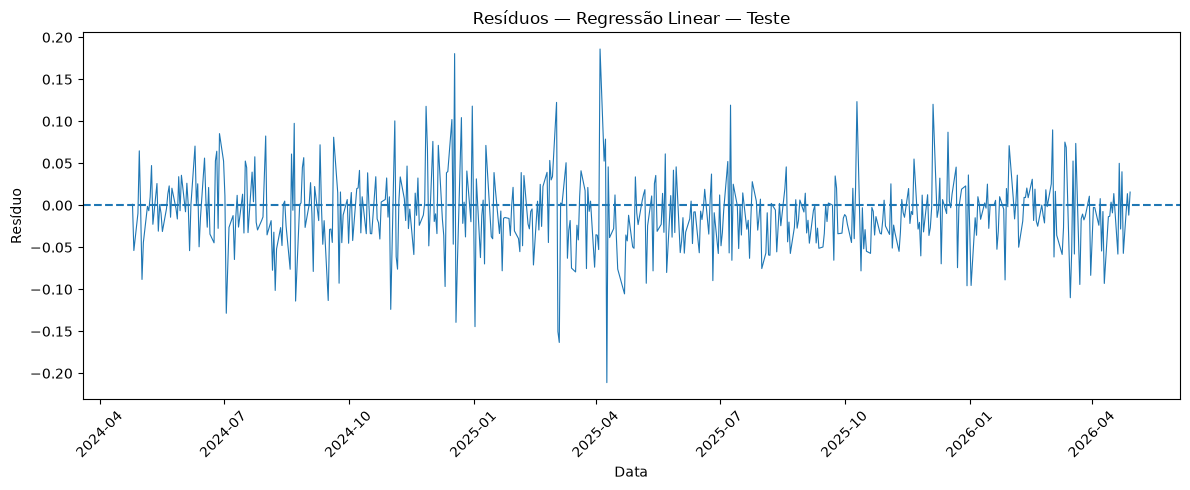

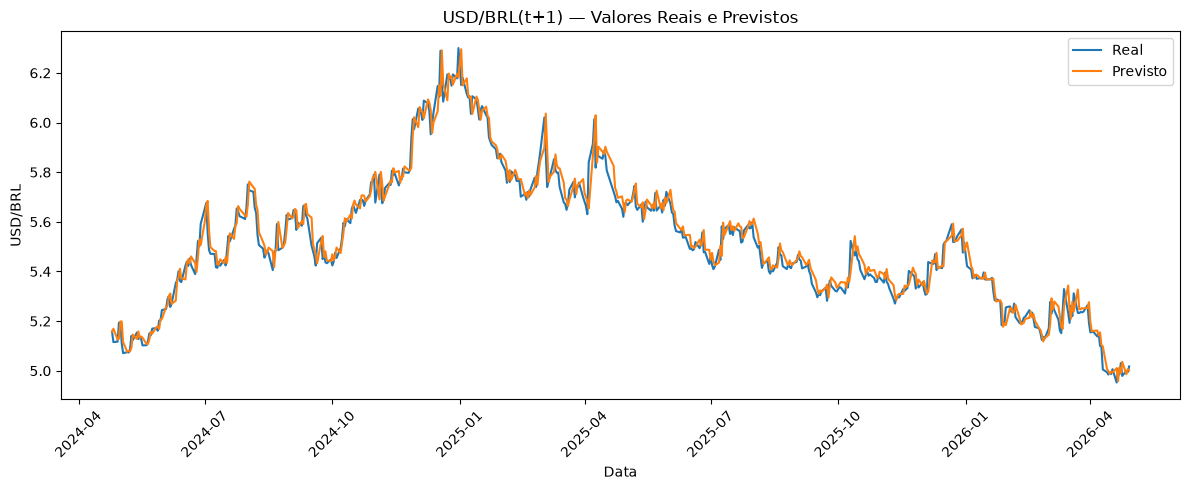

[OK] Gráficos salvos.


In [54]:
# ------------------------------------------------------------
# Resíduos — Treino
# ------------------------------------------------------------

plt.figure(figsize=(12, 5))

plt.plot(
    residuos_treino_df["Data"],
    residuos_treino_df["Residuo"],
    linewidth=0.8
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title(
    "Resíduos — Regressão Linear — Treino"
)

plt.xlabel("Data")
plt.ylabel("Resíduo")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    PATH_TO_SAVE / "residuos_treino.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ------------------------------------------------------------
# Resíduos — Teste
# ------------------------------------------------------------

plt.figure(figsize=(12, 5))

plt.plot(
    residuos_teste_df["Data"],
    residuos_teste_df["Residuo"],
    linewidth=0.8
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title(
    "Resíduos — Regressão Linear — Teste"
)

plt.xlabel("Data")
plt.ylabel("Resíduo")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    PATH_TO_SAVE / "residuos_teste.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ------------------------------------------------------------
# Real x Previsto — Teste
# ------------------------------------------------------------

plt.figure(figsize=(12, 5))

plt.plot(
    X_test.index,
    y_test,
    label="Real"
)

plt.plot(
    X_test.index,
    y_pred_test,
    label="Previsto"
)

plt.title(
    "USD/BRL(t+1) — Valores Reais e Previstos"
)

plt.xlabel("Data")
plt.ylabel("USD/BRL")

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    PATH_TO_SAVE / "real_vs_previsto_teste.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("[OK] Gráficos salvos.")


## Etapa 15 — Salvamento dos resultados

Todos os arquivos desta execução são salvos em `PATH_TO_SAVE`.

A estrutura de saída é independente entre o modelo principal e o experimento com `USD/BRL(t)`.


In [55]:
# ------------------------------------------------------------
# Métricas
# ------------------------------------------------------------

metricas.to_csv(
    PATH_TO_SAVE / "metricas_regressao_linear.csv",
    index=False,
    encoding="utf-8-sig"
)


# ------------------------------------------------------------
# Previsões
# ------------------------------------------------------------

previsoes_treino.to_csv(
    PATH_TO_SAVE / "previsoes_treino.csv",
    index=False,
    encoding="utf-8-sig"
)

previsoes_teste.to_csv(
    PATH_TO_SAVE / "previsoes_teste.csv",
    index=False,
    encoding="utf-8-sig"
)


# ------------------------------------------------------------
# Modelo e scaler
# ------------------------------------------------------------

joblib.dump(
    modelo_lr,
    PATH_TO_SAVE / "regressao_linear.joblib"
)

joblib.dump(
    scaler,
    PATH_TO_SAVE / "standard_scaler.joblib"
)


# ------------------------------------------------------------
# Coeficientes
# ------------------------------------------------------------

coeficientes.to_csv(
    PATH_TO_SAVE / "coeficientes.csv",
    index=False,
    encoding="utf-8-sig"
)


# ------------------------------------------------------------
# OLS
# ------------------------------------------------------------

with open(
    PATH_TO_SAVE / "ols_summary.txt",
    "w",
    encoding="utf-8"
) as arquivo:
    arquivo.write(
        modelo_ols.summary().as_text()
    )


# ------------------------------------------------------------
# Baseline ingênuo
# ------------------------------------------------------------

metricas_naive.to_csv(
    PATH_TO_SAVE / "metricas_baseline_naive.csv",
    index=False,
    encoding="utf-8-sig"
)

previsoes_naive.to_csv(
    PATH_TO_SAVE / "previsoes_baseline_naive.csv",
    index=False,
    encoding="utf-8-sig"
)


# ------------------------------------------------------------
# Comparação
# ------------------------------------------------------------

comparacao.to_csv(
    PATH_TO_SAVE / "comparacao_modelos.csv",
    index=False,
    encoding="utf-8-sig"
)


# ------------------------------------------------------------
# Resíduos
# ------------------------------------------------------------

residuos_treino_df.to_csv(
    PATH_TO_SAVE / "residuos_treino.csv",
    index=False,
    encoding="utf-8-sig"
)

residuos_teste_df.to_csv(
    PATH_TO_SAVE / "residuos_teste.csv",
    index=False,
    encoding="utf-8-sig"
)

print("[OK] Todos os resultados foram salvos.")
print(f"[OK] Pasta: {PATH_TO_SAVE}")


[OK] Todos os resultados foram salvos.
[OK] Pasta: C:\Projetos\PTAX_PREDICTION_MBA_TCC\resultados\regressao_linear\experimento_usd_t


## Etapa 16 — Relatório Markdown

In [56]:
linhas = []

linhas.append(
    "# Regressão Linear — "
    f"{NOME_EXPERIMENTO}"
)
linhas.append("")

linhas.append("## Configuração")
linhas.append("")
linhas.append(
    f"- Experimento: {NOME_EXPERIMENTO}"
)
linhas.append(
    f"- Base: `{PATH_FILE}`"
)
linhas.append(
    f"- Variáveis explicativas: {len(variaveis_explicativas)}"
)
linhas.append(
    f"- Variáveis: {', '.join(variaveis_explicativas)}"
)
linhas.append(
    f"- Target: `{target}`"
)
linhas.append(
    "- Divisão temporal: 80% treino / 20% teste"
)
linhas.append(
    "- Padronização: StandardScaler ajustado somente no treino"
)
linhas.append("")

linhas.append("## Períodos")
linhas.append("")
linhas.append(
    f"- Treino: {X_train.index.min().date()} "
    f"a {X_train.index.max().date()}"
)
linhas.append(
    f"- Teste: {X_test.index.min().date()} "
    f"a {X_test.index.max().date()}"
)
linhas.append("")

linhas.append("## Métricas")
linhas.append("")
linhas.append(
    metricas.to_markdown(index=False)
)
linhas.append("")

linhas.append("## Coeficientes")
linhas.append("")
linhas.append(
    coeficientes.to_markdown(index=False)
)
linhas.append("")

linhas.append("## Baseline Naive")
linhas.append("")
linhas.append(
    "Previsão: y(t+1) = USD/BRL(t)"
)
linhas.append("")
linhas.append(
    metricas_naive.to_markdown(index=False)
)
linhas.append("")

linhas.append("## Comparação")
linhas.append("")
linhas.append(
    comparacao.to_markdown(index=False)
)
linhas.append("")

linhas.append("## Arquivos gerados")
linhas.append("")

for nome in [
    "metricas_regressao_linear.csv",
    "previsoes_treino.csv",
    "previsoes_teste.csv",
    "regressao_linear.joblib",
    "standard_scaler.joblib",
    "coeficientes.csv",
    "ols_summary.txt",
    "metricas_baseline_naive.csv",
    "previsoes_baseline_naive.csv",
    "comparacao_modelos.csv",
    "residuos_treino.csv",
    "residuos_teste.csv",
    "residuos_treino.png",
    "residuos_teste.png",
    "real_vs_previsto_teste.png"
]:
    linhas.append(f"- `{nome}`")

caminho_relatorio = (
    PATH_TO_SAVE /
    "regressao_linear.md"
)

caminho_relatorio.write_text(
    "\n".join(linhas),
    encoding="utf-8"
)

print(
    f"[OK] Relatório salvo em:\n{caminho_relatorio}"
)


[OK] Relatório salvo em:
C:\Projetos\PTAX_PREDICTION_MBA_TCC\resultados\regressao_linear\experimento_usd_t\regressao_linear.md


## Etapa 17 — Validação final dos arquivos

Confere se os principais artefatos da execução foram efetivamente criados.


In [57]:
arquivos_esperados = [
    "metricas_regressao_linear.csv",
    "previsoes_treino.csv",
    "previsoes_teste.csv",
    "regressao_linear.joblib",
    "standard_scaler.joblib",
    "coeficientes.csv",
    "ols_summary.txt",
    "metricas_baseline_naive.csv",
    "previsoes_baseline_naive.csv",
    "comparacao_modelos.csv",
    "residuos_treino.csv",
    "residuos_teste.csv",
    "residuos_treino.png",
    "residuos_teste.png",
    "real_vs_previsto_teste.png",
    "regressao_linear.md"
]

status = pd.DataFrame({
    "Arquivo": arquivos_esperados,
    "Existe": [
        (PATH_TO_SAVE / arquivo).exists()
        for arquivo in arquivos_esperados
    ]
})

display(status)

if not status["Existe"].all():
    faltantes = status.loc[
        ~status["Existe"],
        "Arquivo"
    ].tolist()

    raise FileNotFoundError(
        f"Arquivos não encontrados: {faltantes}"
    )

print("\n[OK] Execução concluída com todos os arquivos esperados.")
print(f"[OK] Resultados em: {PATH_TO_SAVE}")


,Arquivo,Existe
0,metricas_regressao_linear.csv,True
1,previsoes_treino.csv,True
2,previsoes_teste.csv,True
3,regressao_linear.joblib,True
4,standard_scaler.joblib,True
5,coeficientes.csv,True
6,ols_summary.txt,True
7,metricas_baseline_naive.csv,True
8,previsoes_baseline_naive.csv,True
9,comparacao_modelos.csv,True



[OK] Execução concluída com todos os arquivos esperados.
[OK] Resultados em: C:\Projetos\PTAX_PREDICTION_MBA_TCC\resultados\regressao_linear\experimento_usd_t
